<a href="https://colab.research.google.com/github/kishoretamidela-hub/FUTURE_ML_01/blob/main/sales%26Demand_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SALES & DEMAND FORECASTING USING MACHINE LEARNING


Saving sales.csv to sales (1).csv

First Five Rows
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  

Dataset Shape: (6435, 8)

Missing Values
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Training Samples: 5148
Testing Samples : 1287

 Linear Regression
----------------------------------------

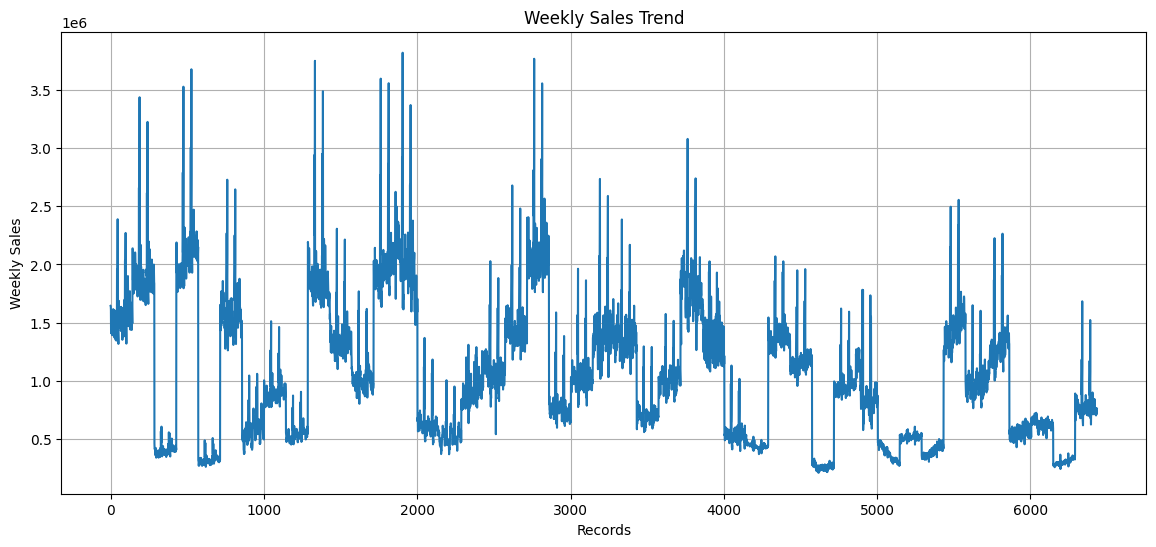

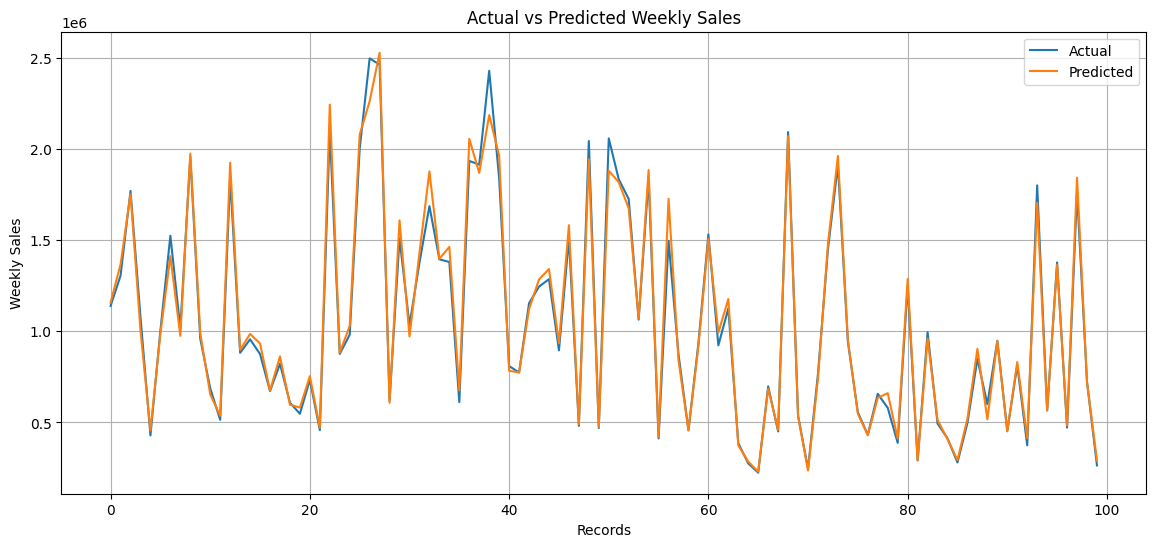

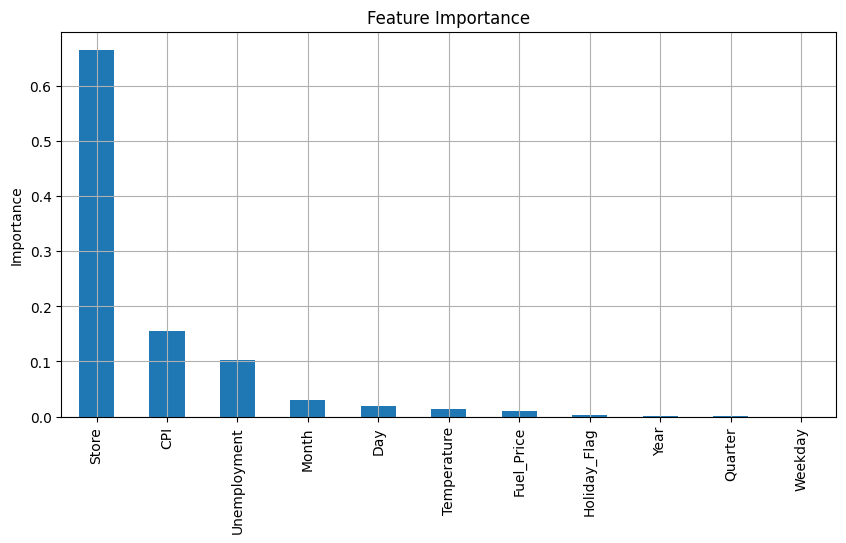

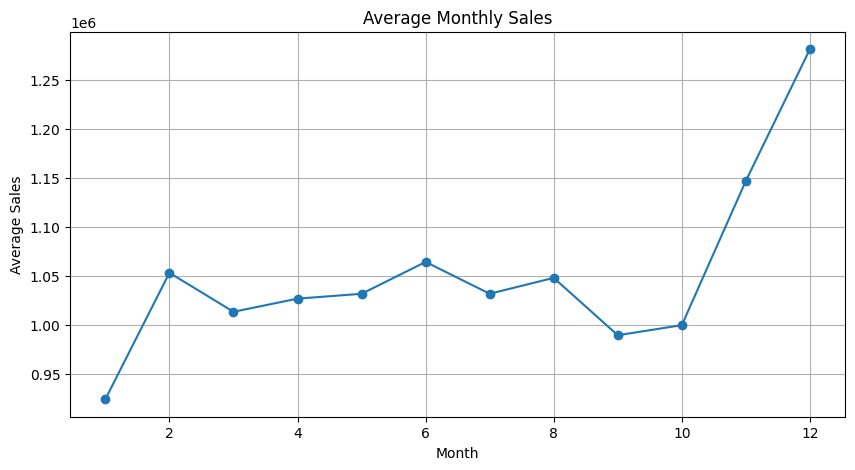


Forecast for Next 12 Months
    Month  Forecasted Sales
0       1      1.776453e+06
1       2      1.953895e+06
2       3      1.929091e+06
3       4      1.929060e+06
4       5      1.927960e+06
5       6      1.929722e+06
6       7      1.926929e+06
7       8      1.928265e+06
8       9      1.906041e+06
9      10      1.900917e+06
10     11      1.943485e+06
11     12      2.081223e+06


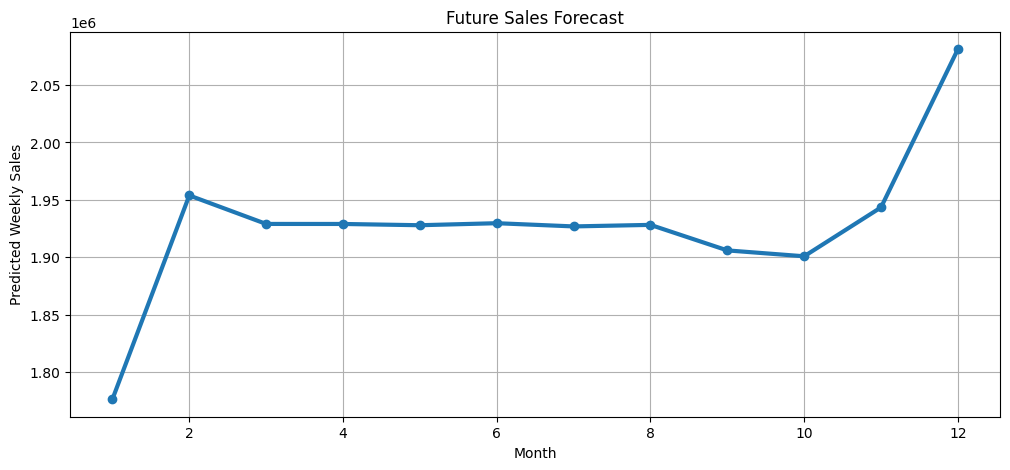


BUSINESS INSIGHTS
• Sales forecasting helps businesses estimate future demand.
• Higher sales periods require increased inventory.
• Holiday seasons can significantly affect sales.
• Managers can optimize staffing using forecasts.
• Forecasting reduces inventory shortages and overstocking.
• Random Forest generally provides better prediction accuracy.

Project Completed Successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("="*60)
print("SALES & DEMAND FORECASTING USING MACHINE LEARNING")
print("="*60)

# Upload Dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("sales.csv")

print("\nFirst Five Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

# Convert Date
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Feature Engineering
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.weekday
df["Quarter"] = df["Date"].dt.quarter

# Remove Date column
df = df.drop("Date", axis=1)

# Features and Target
X = df.drop("Weekly_Sales", axis=1)
y = df["Weekly_Sales"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Evaluation Function
def evaluate(model, actual, pred):
    print("\n",model)
    print("-"*40)
    print("MAE :", round(mean_absolute_error(actual,pred),2))
    print("RMSE:", round(np.sqrt(mean_squared_error(actual,pred)),2))
    print("R2 Score:", round(r2_score(actual,pred),4))

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)

# Sales Trend
plt.figure(figsize=(14,6))
plt.plot(y.values)
plt.title("Weekly Sales Trend")
plt.xlabel("Records")
plt.ylabel("Weekly Sales")
plt.grid(True)
plt.show()

# Actual vs Predicted
plt.figure(figsize=(14,6))
plt.plot(y_test.values[:100],label="Actual")
plt.plot(rf_pred[:100],label="Predicted")
plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Records")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)
plt.show()

# Feature Importance
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,5))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.grid(True)
plt.show()

# Monthly Sales
monthly = df.groupby("Month")["Weekly_Sales"].mean()

plt.figure(figsize=(10,5))
monthly.plot(marker="o")
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.grid(True)
plt.show()

# Future Forecast
future = pd.DataFrame()

future["Store"] = [1]*12
future["Holiday_Flag"] = [0]*12
future["Temperature"] = [df["Temperature"].mean()]*12
future["Fuel_Price"] = [df["Fuel_Price"].mean()]*12
future["CPI"] = [df["CPI"].mean()]*12
future["Unemployment"] = [df["Unemployment"].mean()]*12
future["Year"] = [2013]*12
future["Month"] = list(range(1,13))
future["Day"] = [1]*12
future["Weekday"] = [0]*12
future["Quarter"] = [1,1,1,2,2,2,3,3,3,4,4,4]

forecast = rf.predict(future)

forecast_df = pd.DataFrame({
    "Month":range(1,13),
    "Forecasted Sales":forecast
})

print("\nForecast for Next 12 Months")
print(forecast_df)

plt.figure(figsize=(12,5))
plt.plot(
    forecast_df["Month"],
    forecast_df["Forecasted Sales"],
    marker="o",
    linewidth=3
)
plt.title("Future Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Predicted Weekly Sales")
plt.grid(True)
plt.show()

print("\n" + "="*60)
print("BUSINESS INSIGHTS")
print("="*60)
print("• Sales forecasting helps businesses estimate future demand.")
print("• Higher sales periods require increased inventory.")
print("• Holiday seasons can significantly affect sales.")
print("• Managers can optimize staffing using forecasts.")
print("• Forecasting reduces inventory shortages and overstocking.")
print("• Random Forest generally provides better prediction accuracy.")
print("\nProject Completed Successfully!")